# **Brain Tumour Detection and Classification from MRI Images Using Convolutional Neural Networks**

Dataset Link : https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

## **Dataset Downloading**

**Google Colab**

```python
!pip install -q kaggle

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

!unzip masoudnickparvar/brain-tumor-mri-dataset.zip
```

**VS Code (Recommended)**

In [ ]:
# # Uncomment to execute
# import kaggle

# dataset_url = "masoudnickparvar/brain-tumor-mri-dataset"
# kaggle.api.authenticate()
# kaggle.api.dataset_download_files(dataset_url, path="data", unzip=True)
# print(f"Dataset {dataset_url} downloaded successfully")

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
Dataset masoudnickparvar/brain-tumor-mri-dataset downloaded successfully


**Libraries**

In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tensorflow as tf
import random
from PIL import Image
warnings.filterwarnings('ignore')

## **Image Data**

**Train Data Count**

In [ ]:
train_dir = "data/Training"

list_of_directories = os.listdir(train_dir)

for dir in list_of_directories:
    dir_path = os.path.join(train_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    print(f"{dir} has {count_of_images} images")

glioma has 1400 images
meningioma has 1400 images
notumor has 1400 images
pituitary has 1400 images


**Test Data Count**

In [ ]:
test_dir = "data/Testing"

list_of_directories = os.listdir(test_dir)

for dir in list_of_directories:
    dir_path = os.path.join(test_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    print(f"{dir} has {count_of_images} images")

glioma has 400 images
meningioma has 400 images
notumor has 400 images
pituitary has 400 images


**Test Data Creation**

In [ ]:
train_dir = "data/Training"
val_dir = "data/Validation"

# Create validation directory if not exists
os.makedirs(val_dir, exist_ok=True)

for class_name in os.listdir(train_dir):

    class_train_path = os.path.join(train_dir, class_name)
    class_test_path = os.path.join(val_dir, class_name)

    # Skip if not directory
    if not os.path.isdir(class_train_path):
        continue

    os.makedirs(class_test_path, exist_ok=True)

    images = os.listdir(class_train_path)
    random.shuffle(images)

    # 10% split
    split_size = int(0.10 * len(images))
    val_images = images[:split_size]

    for img in val_images:
        src_path = os.path.join(class_train_path, img)
        dst_path = os.path.join(class_test_path, img)
        shutil.move(src_path, dst_path)

print("Validation data created")

Validation data created


In [ ]:
train_list_of_directories = os.listdir(train_dir)

print("Train Data after Validation Data creation")
print("="*25)
for dir in train_list_of_directories:
    dir_path = os.path.join(train_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    print(f"{dir} has {count_of_images} images")


print("\nTest Data Count")
print("="*25)
test_list_of_directories = os.listdir(test_dir)

for dir in test_list_of_directories:
    dir_path = os.path.join(test_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    print(f"{dir} has {count_of_images} images")

print("\nValidation Data Count")
print("="*25)
val_list_of_directories = os.listdir(val_dir)

for dir in val_list_of_directories:
    dir_path = os.path.join(val_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    print(f"{dir} has {count_of_images} images")

Train Data after Validation Data creation
glioma has 1260 images
meningioma has 1260 images
notumor has 1260 images
pituitary has 1260 images

Test Data Count
glioma has 400 images
meningioma has 400 images
notumor has 400 images
pituitary has 400 images

Validation Data Count
glioma has 140 images
meningioma has 140 images
notumor has 140 images
pituitary has 140 images


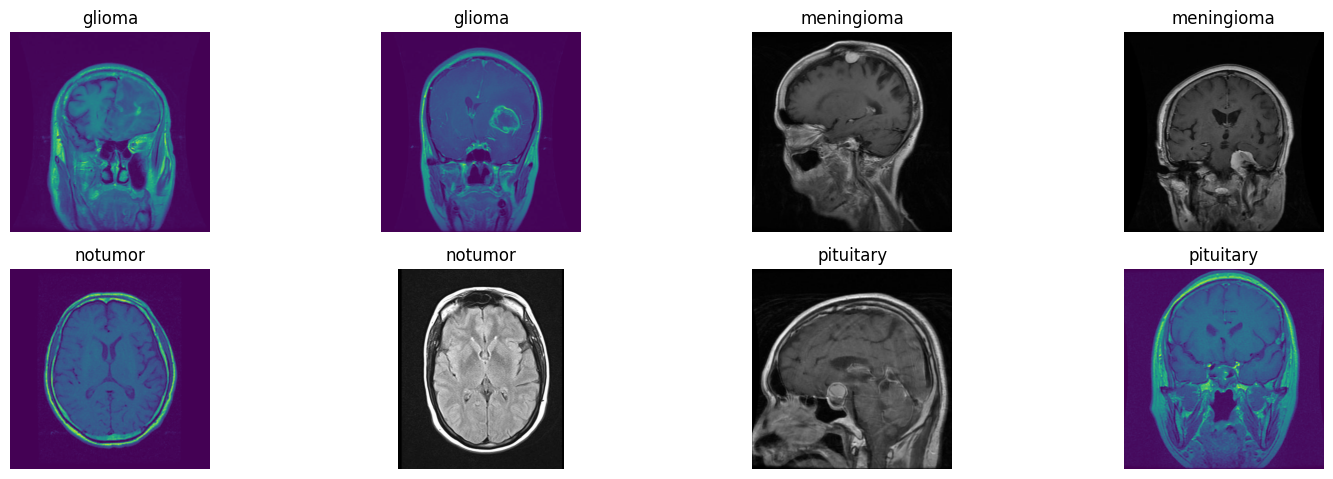

In [ ]:
classes = os.listdir(train_dir)

rows = 5
cols = 4
max_images = rows * cols   # 20

plt.figure(figsize=(15, 12))

plot_index = 1

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)

    images = random.sample(os.listdir(class_path), 2)

    for img_name in images:
        if plot_index > max_images:
            break

        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(rows, cols, plot_index)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

    if plot_index > max_images:
        break

plt.tight_layout()
plt.show()

## **Data Augmentation**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 5040 images belonging to 4 classes.


In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 560 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


## **Model Building**